<a href="https://colab.research.google.com/github/TomaszWlo/learning-git-task/blob/master/9_2_zadanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

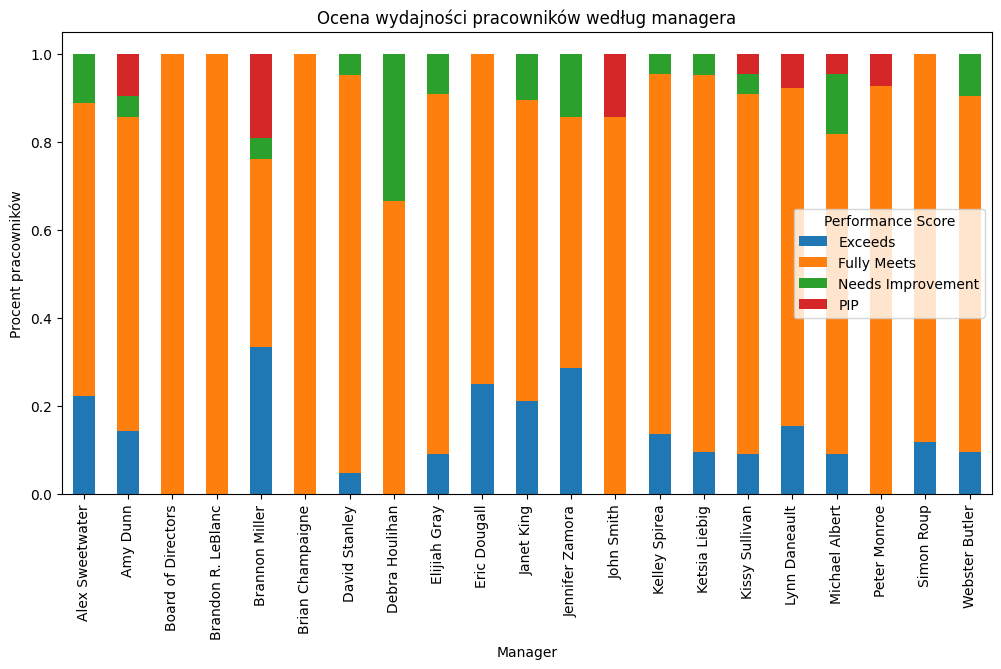

In [2]:
# Punkt 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('HRDataset.csv')

df.dropna(thresh=2,inplace=True)

pd.crosstab(df["ManagerName"], df["PerformanceScore"], normalize="index").plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.ylabel("Procent pracowników")
plt.xlabel("Manager")
plt.title("Ocena wydajności pracowników według managera")
plt.legend(title="Performance Score")
plt.show()



Odpowiedz na 1 punk zadania.

Myślę że tak, istnieje taka zależność. Kilku managerow ocenia swoich podwladnych bardzo dobrze.



In [15]:
# Punkt 2

import datetime as dt

df['DOB'] = pd.to_datetime(df['DOB'],format='%m/%d/%y')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'],format='%m/%d/%y')
df['DateofHire'] = pd.to_datetime(df['DateofHire'],format='%m/%d/%Y')

def count_seniority(row):

    if pd.isnull(row['DateofTermination']):
        end_date = dt.datetime(2019,9,27)
    else:
        end_date = row['DateofTermination']

    return (end_date - row['DateofHire']).days/ 365.25

df['Seniority'] = df.apply(lambda row: count_seniority(row),axis=1)

df.groupby("RecruitmentSource")["Seniority"].mean().sort_values(ascending=False).head()


,Seniority
RecruitmentSource,
Careerbuilder,8.481862
Other,6.453114
Billboard,5.862765
MBTA ads,5.729516
Website Banner Ads,5.721476


Odpowiedź na 2 punkt zadania. Najlpesza metody rekrutacji okazaly sie Carrerbuilder oraz Other czyli inne metody rekrutacji niewymienione w bazie danych.

In [17]:
# Punkt 3

df.groupby("MaritalDesc")["EmpSatisfaction"].mean().sort_values(ascending=False)

,EmpSatisfaction
MaritalDesc,
Widowed,4.250000
Divorced,4.033333
Single,3.970803
Separated,3.833333
Married,3.747967


Odpowiedz na 3 punkt zadania. Możgę stwierdzić że najbardziej zadowolone są wdowy oraz rozwodnicy. Choć reszta grup nie jest specjalnie mniej zadowolona. Wszyscy sa raczej zadowoleni, wszystko jest powyzej sredniej.

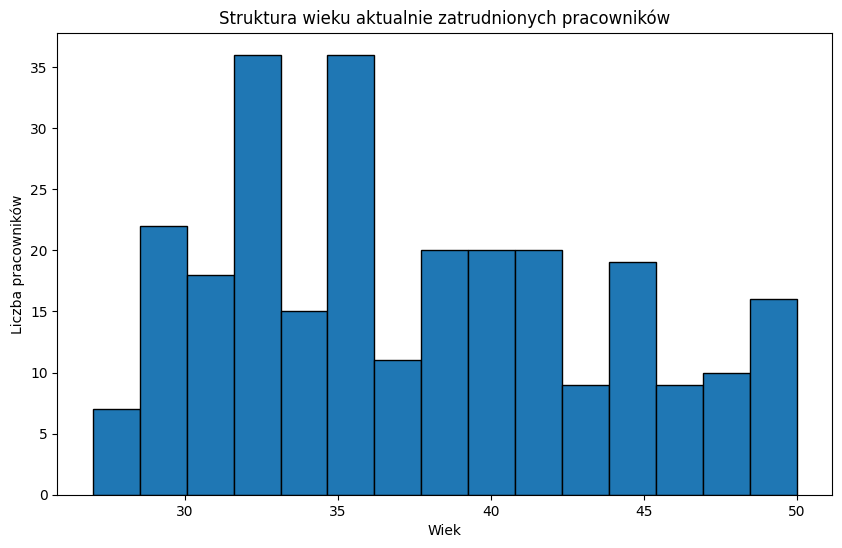

In [31]:
# Punkt 4

today = pd.Timestamp("2019-09-27")

df["Age"] = ((today - df["DOB"]).dt.days / 365.25).astype(int)

age = df[df["Age"] > 0]["Age"]

plt.figure(figsize=(10,6))

plt.hist(age,bins=15,edgecolor="black")


plt.xlabel("Wiek")
plt.ylabel("Liczba pracowników")
plt.title("Struktura wieku aktualnie zatrudnionych pracowników")

plt.show()


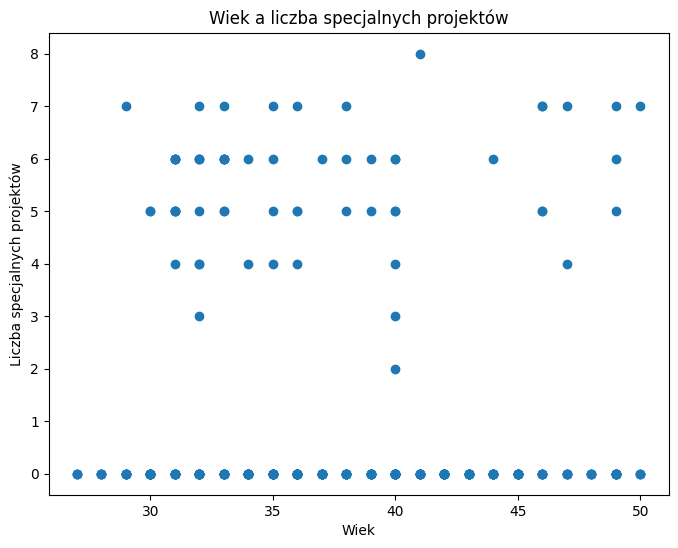

In [35]:
# Punkt 5

analysis_df = df[df["Age"] > 0]

analysis_df["Age"].corr(analysis_df["SpecialProjectsCount"])

plt.figure(figsize=(8,6))

plt.scatter(
    analysis_df["Age"],
    analysis_df["SpecialProjectsCount"]
)

plt.xlabel("Wiek")
plt.ylabel("Liczba specjalnych projektów")
plt.title("Wiek a liczba specjalnych projektów")

plt.show()

Odpowiedź na 5 punkt zadania. Nie, starsi pracownicy nie pracuja nad wieksza liczba specjalnych projektow.  